In [1]:
import pandas as pd

## Dataset Description

According to the research paper *"A Data Mining Approach to Predict Forest Fires using Meteorological Data"*, the dataset used for the **SVM model** includes the following variables:

| Variable | Description |
|---------|-------------|
| **X** | X-axis spatial coordinate within the Montesinho Park map (range: 1–9) |
| **Y** | Y-axis spatial coordinate within the Montesinho Park map (range: 1–9) |
| **month** | Month of the year (January–December) |
| **day** | Day of the week (Monday–Sunday) |
| **FFMC** | Fine Fuel Moisture Code from the Fire Weather Index (FWI) system |
| **DMC** | Duff Moisture Code from the Fire Weather Index (FWI) system |
| **DC** | Drought Code from the Fire Weather Index (FWI) system |
| **ISI** | Initial Spread Index from the Fire Weather Index (FWI) system |
| **temp** | Outside temperature (°C) |
| **RH** | Outside relative humidity (%) |
| **wind** | Outside wind speed (km/h) |
| **rain** | Outside rainfall (mm/m²) |

In [2]:
df_weather = pd.read_csv('../../extracted/FInal_weather/cariboo_master_weather_2012-01-01_2023-12-31.csv')

In [3]:
df_weather.columns

Index(['Date', 'Zone_Name', 'temperature_2m_mean', 'temperature_2m_max',
       'precipitation_sum', 'wind_speed_10m_max', 'relative_humidity_2m_mean',
       'relative_humidity_2m_min', 'dew_point_2m_mean', 'vpd_mean_kpa',
       'vpd_max_kpa'],
      dtype='object')

In [4]:
print("weather data date range:", df_weather['Date'].min(), "to", df_weather['Date'].max()  )

weather data date range: 2012-01-01 to 2023-12-31


In [5]:
df_fire_data= pd.read_csv('../../extracted/fire_data/cariboo_historical_fires_2012_2023.csv')

In [6]:
df_fire_data.columns

Index(['longitude', 'latitude', 'FIRE_DATE', 'FIRE_CAUSE',
       'FIRE_SIZE_HECTARES', 'FIRE_YEAR'],
      dtype='object')

In [7]:
print("fire data date range:", df_fire_data['FIRE_DATE'].min(), "to", df_fire_data['FIRE_DATE'].max()  )

fire data date range: 2012-04-06 to 2024-03-26


In [8]:
print("truncating fire and weather data to 2012-04-06 to 2023-12-31 ")
df_weather_truncated = df_weather[(df_weather['Date'] >= '2012-04-06') & (df_weather['Date'] <= '2023-12-31')]
df_fire_data_truncated = df_fire_data[(df_fire_data['FIRE_DATE'] >= '2012-04-06') & (df_fire_data['FIRE_DATE'] <= '2023-12-31')]
print("truncated weather data date range:", df_weather_truncated['Date'].min(), "to", df_weather_truncated['Date'].max()  )
print("truncated fire data date range:", df_fire_data_truncated['FIRE_DATE'].min(), "to", df_fire_data_truncated['FIRE_DATE'].max()  )  



truncating fire and weather data to 2012-04-06 to 2023-12-31 
truncated weather data date range: 2012-04-06 to 2023-12-31
truncated fire data date range: 2012-04-06 to 2023-12-05


In [9]:
df_weather_truncated.columns

Index(['Date', 'Zone_Name', 'temperature_2m_mean', 'temperature_2m_max',
       'precipitation_sum', 'wind_speed_10m_max', 'relative_humidity_2m_mean',
       'relative_humidity_2m_min', 'dew_point_2m_mean', 'vpd_mean_kpa',
       'vpd_max_kpa'],
      dtype='object')

histogram of burned area (in hectares):


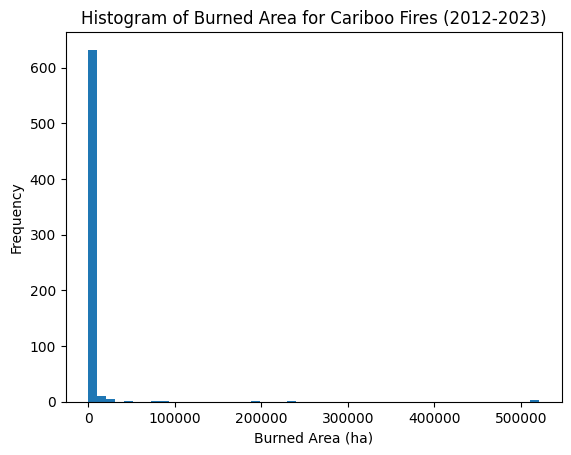

In [10]:
print("histogram of burned area (in hectares):")
import matplotlib.pyplot as plt
plt.hist(df_fire_data_truncated['FIRE_SIZE_HECTARES'], bins=50)
plt.xlabel('Burned Area (ha)')
plt.ylabel('Frequency')
plt.title('Histogram of Burned Area for Cariboo Fires (2012-2023)')
plt.show()


calcuating burned area after applying log transformation to reduce skewness
histogram of log-transformed burned area:


C:\Users\rajpu\AppData\Local\Temp\ipykernel_16252\445328643.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fire_data_truncated['LOG_BURNED_AREA'] = np.log1p(df_fire_data_truncated['FIRE_SIZE_HECTARES'])


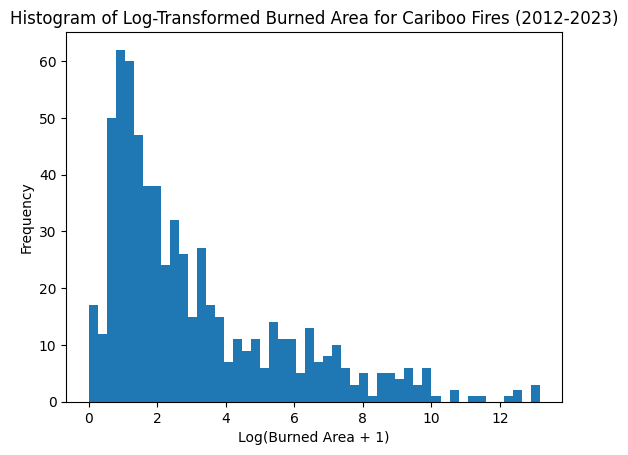

In [11]:
print('calcuating burned area after applying log transformation to reduce skewness')
import numpy as np
df_fire_data_truncated['LOG_BURNED_AREA'] = np.log1p(df_fire_data_truncated['FIRE_SIZE_HECTARES'])
print("histogram of log-transformed burned area:")
plt.hist(df_fire_data_truncated['LOG_BURNED_AREA'], bins=50)
plt.xlabel('Log(Burned Area + 1)')
plt.ylabel('Frequency')
plt.title('Histogram of Log-Transformed Burned Area for Cariboo Fires (2012-2023)')
plt.show()


In [12]:
df_fire_data_truncated.columns

Index(['longitude', 'latitude', 'FIRE_DATE', 'FIRE_CAUSE',
       'FIRE_SIZE_HECTARES', 'FIRE_YEAR', 'LOG_BURNED_AREA'],
      dtype='object')

## Required FWI Components

| Variable | Description |
|----------|-------------|
| **FFMC** | Fine Fuel Moisture Code from the Fire Weather Index (FWI) system |
| **DMC**  | Duff Moisture Code from the Fire Weather Index (FWI) system |
| **DC**   | Drought Code from the Fire Weather Index (FWI) system |
| **ISI**  | Initial Spread Index from the Fire Weather Index (FWI) system |

## Data Preparation

Before calculating or extracting the **FWI components**, we need to join the **weather dataset** with the **fire dataset**.

- The **weather dataset** contains the column **`zone_name`**.
- The **fire dataset** contains **latitude (`lat`)** and **longitude (`long`)**.

Each fire record must be mapped to the correct **weather zone** so that the corresponding **weather conditions** can be used. This combined data will then be used as input for the **SVM model** to predict fire occurrence in a given zone.

In [13]:
import geopandas as gpd

In [14]:
zones_gdf = gpd.read_file('../../extracted\zone_data\cariboo_zones.geojson')

<>:1: SyntaxWarning: invalid escape sequence '\z'
<>:1: SyntaxWarning: invalid escape sequence '\z'
C:\Users\rajpu\AppData\Local\Temp\ipykernel_16252\3835555267.py:1: SyntaxWarning: invalid escape sequence '\z'
  zones_gdf = gpd.read_file('../../extracted\zone_data\cariboo_zones.geojson')


In [15]:
zones_gdf.columns

Index(['Zone_Name', 'geometry'], dtype='object')

In [16]:
df_weather['Date'] = pd.to_datetime(df_weather['Date'])

## Verifying whether zone data can be linked with latitude and longitude data from the fire data frame

Before joining the fire and weather datasets using the zone name as the key, the data consistency is verified to ensure that the join correctly correlates the corresponding records.

In [17]:
target_year = 2021
df_weather_year=df_weather[df_weather['Date'].dt.year == target_year]

In [18]:
df_weather_year.columns

Index(['Date', 'Zone_Name', 'temperature_2m_mean', 'temperature_2m_max',
       'precipitation_sum', 'wind_speed_10m_max', 'relative_humidity_2m_mean',
       'relative_humidity_2m_min', 'dew_point_2m_mean', 'vpd_mean_kpa',
       'vpd_max_kpa'],
      dtype='object')

In [19]:
feature_to_plot = 'temperature_2m_mean'

In [20]:
yearly_zone_stats =df_weather_year.groupby('Zone_Name')[feature_to_plot].mean().reset_index()

In [21]:
map_data = zones_gdf.merge(yearly_zone_stats, left_on='Zone_Name', right_on='Zone_Name', how='left')

In [22]:
map_data.columns

Index(['Zone_Name', 'geometry', 'temperature_2m_mean'], dtype='object')


Average temperature_2m_mean in Cariboo Fire Zones (2021)
                Zone_Name  temperature_2m_mean
 100 Mile House Fire Zone             4.103647
Central Cariboo Fire Zone             3.014089
        Quesnel Fire Zone             2.842733
      Chilcotin Fire Zone             1.975699


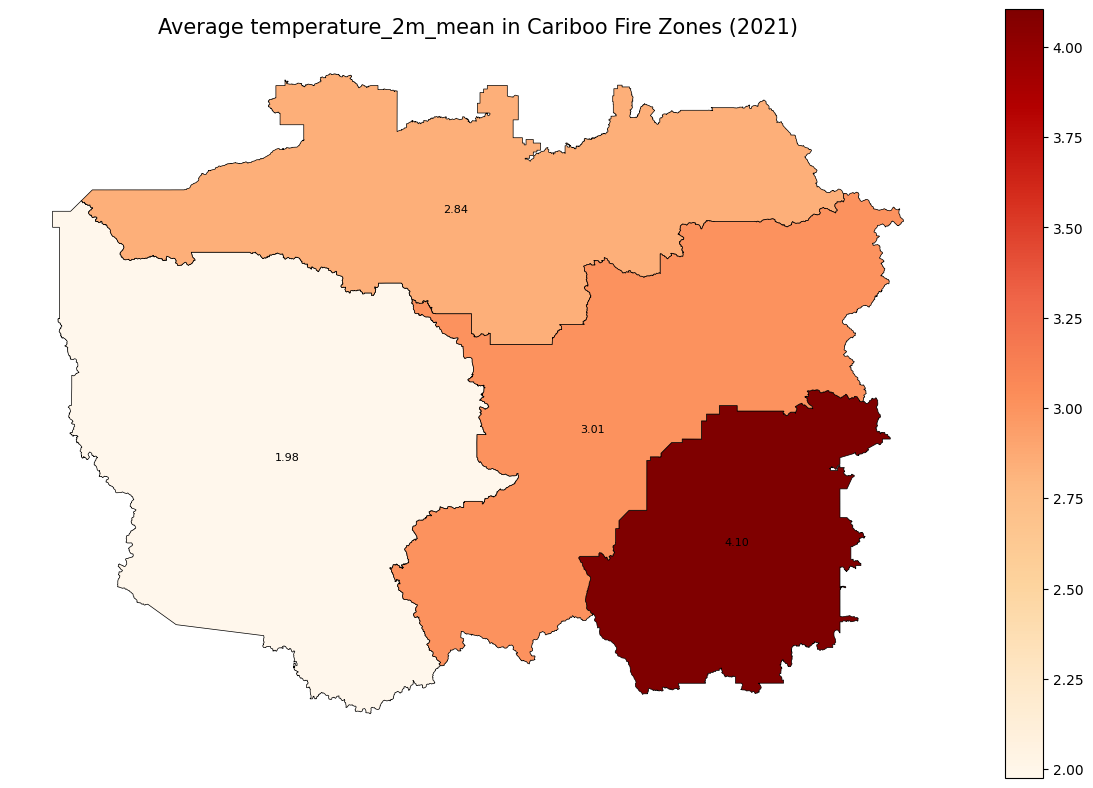

In [23]:
import matplotlib.pyplot as plt


print(f"\nAverage {feature_to_plot} in Cariboo Fire Zones ({target_year})")

print(
    map_data[['Zone_Name', 'temperature_2m_mean']]
    .sort_values(feature_to_plot, ascending=False, na_position='last')
    .to_string(index=False)
)

map_data['label_point'] = map_data.geometry.representative_point()

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

map_data.plot(
    column=feature_to_plot,
    ax=ax,
    legend=True,
    cmap='OrRd',
    edgecolor='black',
    linewidth=0.5,
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'}
)


for _, row in map_data.iterrows():
 
        x, y = row['label_point'].x, row['label_point'].y
        ax.annotate(
            text=f"{row['temperature_2m_mean']:.2f}",
            xy=(x, y),
            ha='center',
            va='center',
            fontsize=8,
            color='black'
        )

plt.title(f'Average temperature_2m_mean in Cariboo Fire Zones ({target_year})', fontsize=15)
ax.set_axis_off()

plt.tight_layout()
plt.show()


C:\Users\rajpu\AppData\Local\Temp\ipykernel_16252\3662273652.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


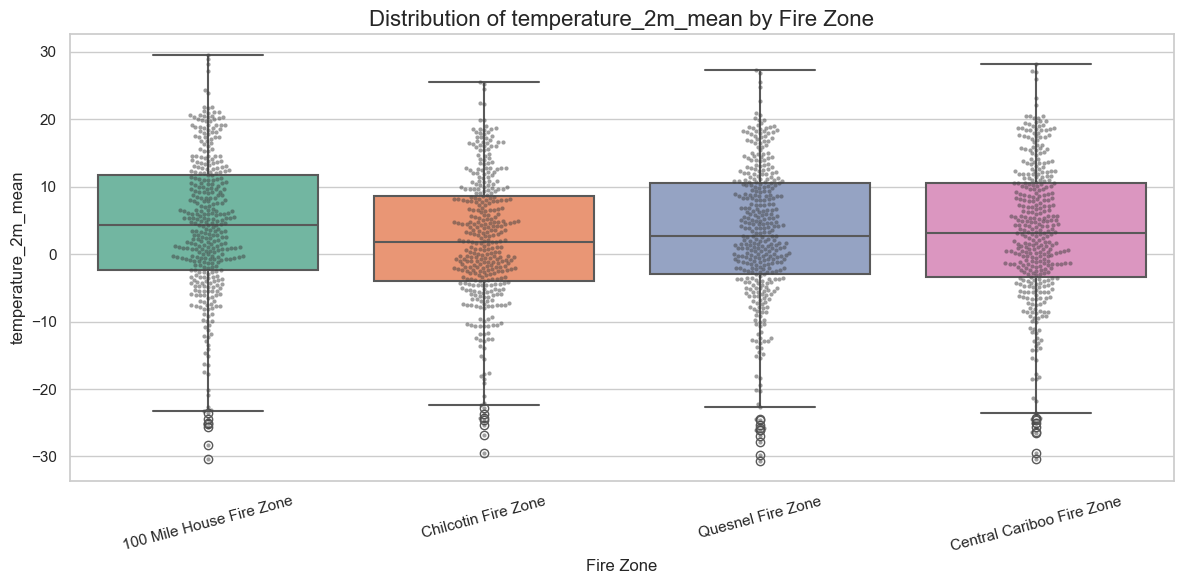

In [24]:
import seaborn as sns








feature_to_plot = 'temperature_2m_mean'

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))


sns.boxplot(
    data=df_weather_year,
    x='Zone_Name',
    y=feature_to_plot,
    palette='Set2',
    linewidth=1.5
)

sns.swarmplot(
    data=df_weather_year,
    x='Zone_Name',
    y=feature_to_plot,
    color=".25",
    alpha=0.5,
    size=3
)


plt.title(f'Distribution of {feature_to_plot} by Fire Zone', fontsize=16)
plt.xlabel('Fire Zone', fontsize=12)
plt.ylabel(f'{feature_to_plot}', fontsize=12)

plt.xticks(rotation=15) 

plt.tight_layout()
plt.show()

In [25]:
from shapely.geometry import Point

In [26]:
geometry = [Point(xy) for xy in zip(df_fire_data['longitude'], df_fire_data['latitude'])]

In [27]:
fire_gdf = gpd.GeoDataFrame(df_fire_data, geometry=geometry, crs="EPSG:4326")

In [28]:
if zones_gdf.crs != "EPSG:4326":
    zones_gdf = zones_gdf.to_crs("EPSG:4326")

In [29]:
df_fire_mapped = gpd.sjoin(fire_gdf, zones_gdf[['Zone_Name', 'geometry']], how="left", predicate="within")

In [30]:
df_fire_final = df_fire_mapped.drop(columns=['geometry', 'index_right'])

In [31]:
print(df_fire_final[['FIRE_DATE', 'latitude', 'longitude', 'Zone_Name']].head())

    FIRE_DATE   latitude   longitude            Zone_Name
0  2012-04-09  51.996181 -123.158673  Chilcotin Fire Zone
1  2012-04-24  51.993041 -123.158693  Chilcotin Fire Zone
2  2012-05-03  52.144246 -123.927720  Chilcotin Fire Zone
3  2012-05-05  52.000324 -123.162839  Chilcotin Fire Zone
4  2012-05-05  52.031283 -123.188761  Chilcotin Fire Zone


In [32]:
df_fire_final.columns

Index(['longitude', 'latitude', 'FIRE_DATE', 'FIRE_CAUSE',
       'FIRE_SIZE_HECTARES', 'FIRE_YEAR', 'Zone_Name'],
      dtype='object')


Scenario 1: Exact Fire Distribution (points) - total fires per zone
                Zone_Name  Fire_Count
 100 Mile House Fire Zone          27
        Quesnel Fire Zone          22
Central Cariboo Fire Zone          19
      Chilcotin Fire Zone          19

Scenario 2: Total Fire Count by Zone (polygon map)
                Zone_Name  Fire_Count
 100 Mile House Fire Zone          27
        Quesnel Fire Zone          22
      Chilcotin Fire Zone          19
Central Cariboo Fire Zone          19


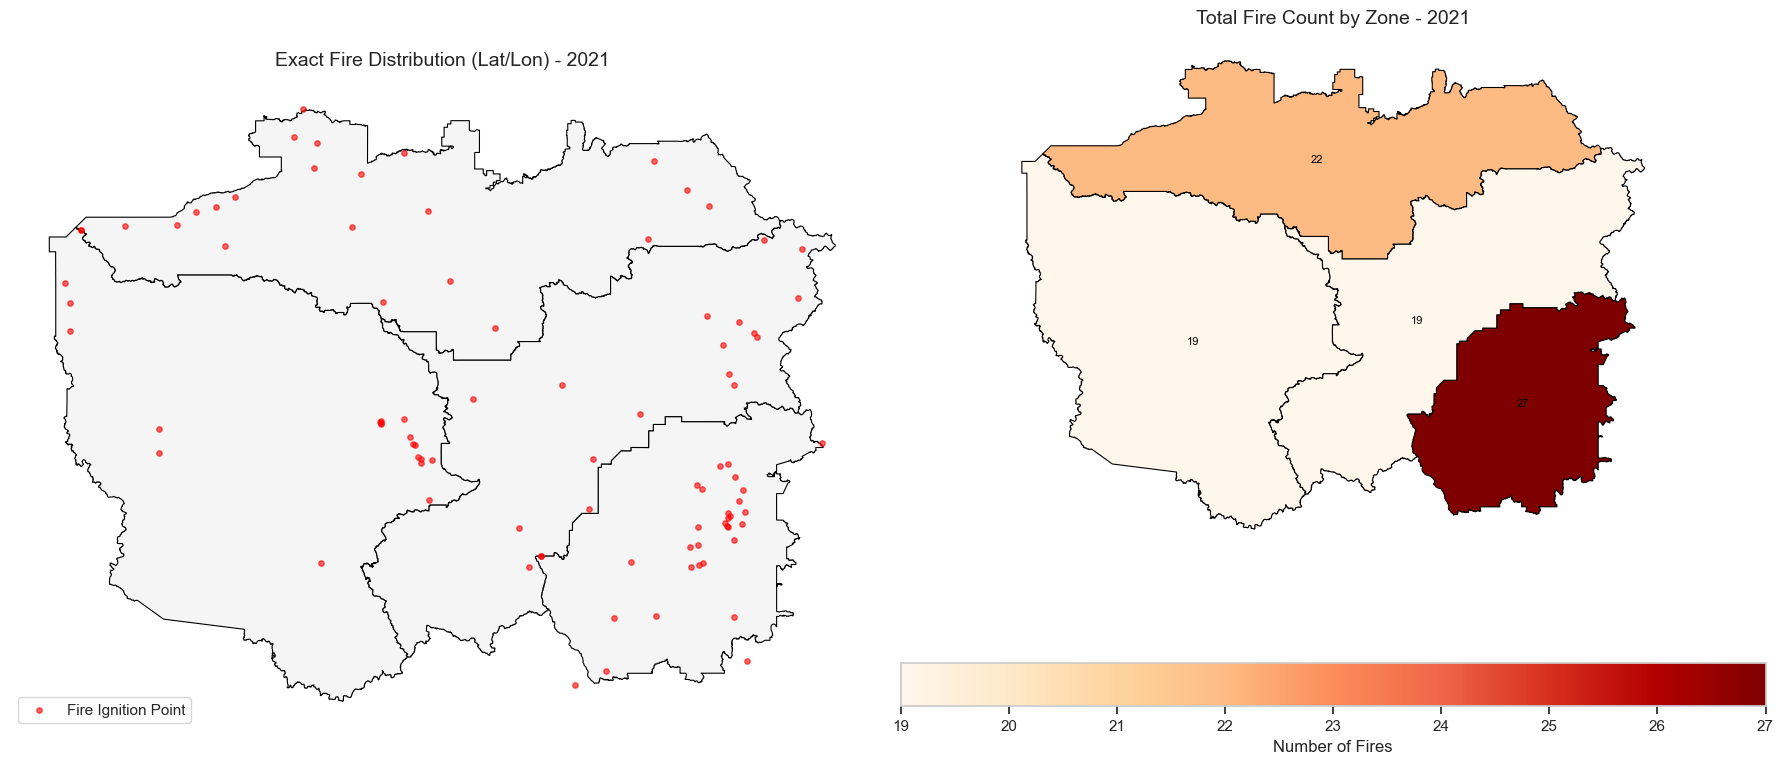

In [33]:
import matplotlib.pyplot as plt
import geopandas as gpd

fires_2021 = df_fire_final[df_fire_final['FIRE_YEAR'] == 2021].copy()


fires_2021_gdf = gpd.GeoDataFrame(
    fires_2021,
    geometry=gpd.points_from_xy(fires_2021['longitude'], fires_2021['latitude']),
    crs="EPSG:4326"
)

zone_counts_2021 = (
    fires_2021.groupby('Zone_Name')
    .size()
    .reset_index(name='Fire_Count')
    .sort_values('Fire_Count', ascending=False)
)

zones_with_counts = zones_gdf.merge(zone_counts_2021, on='Zone_Name', how='left')
zones_with_counts['Fire_Count'] = zones_with_counts['Fire_Count'].fillna(0).astype(int)

print("\nScenario 1: Exact Fire Distribution (points) - total fires per zone")
print(zone_counts_2021.to_string(index=False))

print("\nScenario 2: Total Fire Count by Zone (polygon map)")
print(
    zones_with_counts[['Zone_Name', 'Fire_Count']]
    .sort_values('Fire_Count', ascending=False)
    .to_string(index=False)
)

zones_with_counts['label_point'] = zones_with_counts.geometry.representative_point()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

zones_gdf.plot(ax=axes[0], color='whitesmoke', edgecolor='black', linewidth=0.8)
fires_2021_gdf.plot(ax=axes[0], color='red', markersize=15, alpha=0.6, label='Fire Ignition Point')

axes[0].set_title('Exact Fire Distribution (Lat/Lon) - 2021', fontsize=14, pad=10)
axes[0].axis('off')
axes[0].legend(loc='lower left')

zones_with_counts.plot(
    ax=axes[1],
    column='Fire_Count',
    cmap='OrRd',
    edgecolor='black',
    linewidth=0.8,
    legend=True,
    legend_kwds={'label': "Number of Fires", 'orientation': "horizontal"}
)

for _, row in zones_with_counts.iterrows():
    x, y = row['label_point'].x, row['label_point'].y
    axes[1].annotate(
        text=str(row['Fire_Count']),
        xy=(x, y),
        ha='center',
        va='center',
        fontsize=8,
        color='black'
    )

axes[1].set_title('Total Fire Count by Zone - 2021', fontsize=14, pad=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()


## since we have validated that the spatial mapping works correctly, we can proceed with the  combining all three DataFrames into a single, clean DataFrame ready for the Support Vector Machine


In [34]:
geometry = [Point(xy) for xy in zip(df_fire_data_truncated['longitude'], df_fire_data_truncated['latitude'])]
fire_gdf = gpd.GeoDataFrame(df_fire_data_truncated, geometry=geometry, crs="EPSG:4326")

In [35]:
if zones_gdf.crs != "EPSG:4326":
    zones_gdf = zones_gdf.to_crs("EPSG:4326")

In [36]:
fire_mapped_gdf = gpd.sjoin(fire_gdf, zones_gdf[['Zone_Name', 'geometry']], how="inner", predicate="intersects")

df_fire_mapped = fire_mapped_gdf.drop(columns=['geometry', 'index_right'])

In [37]:
df_fire_mapped['FIRE_DATE'] = pd.to_datetime(df_fire_mapped['FIRE_DATE']).dt.normalize()
df_weather_truncated['Date'] = pd.to_datetime(df_weather_truncated['Date']).dt.normalize()

C:\Users\rajpu\AppData\Local\Temp\ipykernel_16252\3405680562.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_weather_truncated['Date'] = pd.to_datetime(df_weather_truncated['Date']).dt.normalize()


In [38]:
df_final_merged = pd.merge(
    df_fire_mapped, 
    df_weather_truncated, 
    left_on=['Zone_Name', 'FIRE_DATE'], 
    right_on=['Zone_Name', 'Date'], 
    how='inner'
)

In [39]:
print("Final Dataset Shape:", df_final_merged.shape)
print("\nFinal Dataset Columns:\n", df_final_merged.columns.tolist())
display(df_final_merged.head())

Final Dataset Shape: (641, 18)

Final Dataset Columns:
 ['longitude', 'latitude', 'FIRE_DATE', 'FIRE_CAUSE', 'FIRE_SIZE_HECTARES', 'FIRE_YEAR', 'LOG_BURNED_AREA', 'Zone_Name', 'Date', 'temperature_2m_mean', 'temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max', 'relative_humidity_2m_mean', 'relative_humidity_2m_min', 'dew_point_2m_mean', 'vpd_mean_kpa', 'vpd_max_kpa']


,longitude,latitude,FIRE_DATE,FIRE_CAUSE,FIRE_SIZE_HECTARES,FIRE_YEAR,LOG_BURNED_AREA,Zone_Name,Date,temperature_2m_mean,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,relative_humidity_2m_min,dew_point_2m_mean,vpd_mean_kpa,vpd_max_kpa
0,-123.158673,51.996181,2012-04-09,Person,1.4,2012,0.875469,Chilcotin Fire Zone,2012-04-09,1.851868,7.651276,0.262089,1.138761,56.998950,38.030376,-5.773254,0.300232,0.649166
1,-123.158693,51.993041,2012-04-24,Person,0.2,2012,0.182322,Chilcotin Fire Zone,2012-04-24,3.473297,7.516815,3.535670,3.171666,69.228860,52.299710,-1.635681,0.241123,0.495116
2,-123.927720,52.144246,2012-05-03,Person,8.9,2012,2.292535,Chilcotin Fire Zone,2012-05-03,1.808472,5.206146,3.568717,1.951373,75.371820,59.322388,-2.085632,0.171419,0.359974
3,-123.162839,52.000324,2012-05-05,Person,2.5,2012,1.252763,Chilcotin Fire Zone,2012-05-05,1.726471,6.119598,0.421706,3.139682,59.487923,43.693750,-5.328491,0.280322,0.530901
4,-123.188761,52.031283,2012-05-05,Person,2.9,2012,1.360977,Chilcotin Fire Zone,2012-05-05,1.726471,6.119598,0.421706,3.139682,59.487923,43.693750,-5.328491,0.280322,0.530901


In [43]:
df_final_merged['Date'].min(),df_final_merged['Date'].max()

(Timestamp('2012-04-06 00:00:00'), Timestamp('2023-12-05 00:00:00'))

## visulizing data before adding FWI components to data frame 


In [40]:
!pip install nbformat

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\rajpu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [41]:

import plotly.express as px

df = df_final_merged.copy()
df['FIRE_DATE'] = pd.to_datetime(df['FIRE_DATE'], errors='coerce')
df_2021 = df[df['FIRE_YEAR'] == 2021].copy()

fig1 = px.scatter(
    df_2021,
    x='temperature_2m_mean',
    y='FIRE_SIZE_HECTARES',
    color='FIRE_CAUSE',
    hover_data=['FIRE_DATE', 'Zone_Name', 'precipitation_sum', 'wind_speed_10m_max'],
    log_y=True,
    title='2021 Fire Size vs Temperature'
)
fig1.show()

daily = df_2021.groupby(df_2021['FIRE_DATE'].dt.date)['FIRE_SIZE_HECTARES'].sum().reset_index()
daily.columns = ['Date', 'Burned_ha']
fig2 = px.line(daily, x='Date', y='Burned_ha', title='2021 Daily Burned Area')
fig2.show()

fig3 = px.scatter_mapbox(
    df_2021,
    lat='latitude',
    lon='longitude',
    color='FIRE_SIZE_HECTARES',
    size='FIRE_SIZE_HECTARES',
    hover_name='Zone_Name',
    hover_data=['FIRE_DATE', 'FIRE_CAUSE'],
    zoom=4,
    mapbox_style='carto-positron',
    title='2021 Fire Locations'
)
fig3.show()


C:\Users\rajpu\AppData\Local\Temp\ipykernel_16252\3617323251.py:23: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



## before running the svm model we need following FWI Components

| Variable | Description |
|----------|-------------|
| **FFMC** | Fine Fuel Moisture Code from the Fire Weather Index (FWI) system |
| **DMC**  | Duff Moisture Code from the Fire Weather Index (FWI) system |
| **DC**   | Drought Code from the Fire Weather Index (FWI) system |
| **ISI**  | Initial Spread Index from the Fire Weather Index (FWI) system |

**please see FWI_ext in extraction_transformation_scripts folder for the extraction method used for FWI(ire Weather Index) componenets 

In [ ]:
print()